## Missing values

In [ ]:
# =========================================================
# STEP 0: Import Required Libraries
# =========================================================
# numpy  -> numerical operations
# pandas -> data manipulation
# SimpleImputer -> handling missing values
# =========================================================

In [1]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer

In [2]:
# Fix random seed so results are reproducible
np.random.seed(42)

# Total number of records
N = 200

In [3]:
# =========================================================
# STEP 1: Create Base Dataset (No Missing Values Initially)
# =========================================================
# At this stage, data is CLEAN and IDEAL
# =========================================================

df = pd.DataFrame({
    "student_id": range(1, N + 1),                # Unique student identifier
    "age": np.random.randint(18, 25, N),          # Age between 18–24
    "gender": np.random.choice(["Male", "Female"], N),
    "study_hours": np.random.normal(5, 2, N),     # Avg study hours per day
    "attendance": np.random.uniform(60, 100, N),  # Attendance percentage
    "exam_score": np.random.normal(70, 10, N)     # Exam marks
})

In [4]:
# Preview dataset
df.head()

,student_id,age,gender,study_hours,attendance,exam_score
0,1,24,Female,2.339852,81.134805,77.974842
1,2,21,Male,4.949425,77.453433,71.452041
2,3,22,Male,7.686336,92.084370,87.951646
3,4,24,Female,3.530905,99.116027,69.254924
4,5,20,Female,3.080211,82.240202,75.663401


In [5]:
# =========================================================
# STEP 2: Introduce REAL-WORLD Missing Values
# =========================================================
# In real projects, data NEVER comes clean.
# We manually introduce different missing patterns.
# =========================================================


In [ ]:
# ---------------------------------------------------------
# 2.1 MCAR – Missing Completely At Random
# ---------------------------------------------------------
# Missing values appear randomly.
# No relationship with any column.
# Example: sensor failure, random data loss
# ---------------------------------------------------------

In [6]:
random_idx = np.random.choice(df.index, size=20, replace=False)
df.loc[random_idx, "study_hours"] = np.nan

In [7]:
df.head()

,student_id,age,gender,study_hours,attendance,exam_score
0,1,24,Female,2.339852,81.134805,77.974842
1,2,21,Male,4.949425,77.453433,71.452041
2,3,22,Male,7.686336,92.084370,87.951646
3,4,24,Female,3.530905,99.116027,69.254924
4,5,20,Female,NaN,82.240202,75.663401


In [8]:
# ---------------------------------------------------------
# 2.2 MAR – Missing At Random
# ---------------------------------------------------------
# Missing depends on another variable.
# Example: students with LOW attendance
# often skip exams → exam_score missing
# ---------------------------------------------------------

df.loc[df["attendance"] < 70, "exam_score"] = np.nan


In [9]:
# ---------------------------------------------------------
# 2.3 MNAR – Missing Not At Random
# ---------------------------------------------------------
# Missing depends on the value itself.
# Example: students with VERY LOW study hours
# intentionally do not report it.
# ---------------------------------------------------------

df.loc[df["study_hours"] < 2, "study_hours"] = np.nan


In [10]:
df.head()

,student_id,age,gender,study_hours,attendance,exam_score
0,1,24,Female,2.339852,81.134805,77.974842
1,2,21,Male,4.949425,77.453433,71.452041
2,3,22,Male,7.686336,92.084370,87.951646
3,4,24,Female,3.530905,99.116027,69.254924
4,5,20,Female,NaN,82.240202,75.663401


In [ ]:
# ---------------------------------------------------------
# 2.4 Structural Missing Values
# ---------------------------------------------------------
# Missing value is LOGICALLY correct.
# Example: pregnancy hours only apply to females.
# ---------------------------------------------------------

In [11]:
df["pregnancy_hours"] = np.where(
    df["gender"] == "Female",
    np.random.uniform(0, 10, N),
    np.nan   # Not applicable → correct missing
)

In [12]:
# ---------------------------------------------------------
# 2.5 Random Missing in Categorical Column
# ---------------------------------------------------------
# Example: gender not recorded in some forms
# ---------------------------------------------------------

cat_idx = np.random.choice(df.index, size=15, replace=False)
df.loc[cat_idx, "gender"] = np.nan


In [13]:
# =========================================================
# STEP 3: Understand Missing Value Situation
# =========================================================

print("Missing value count BEFORE handling:\n")
print(df.isna().sum())


Missing value count BEFORE handling:

student_id          0
age                 0
gender             15
study_hours        30
attendance          0
exam_score         48
pregnancy_hours    93
dtype: int64


In [15]:
df.dtypes

student_id           int64
age                  int32
gender              object
study_hours        float64
attendance         float64
exam_score         float64
pregnancy_hours    float64
dtype: object

In [14]:
# =========================================================
# STEP 4: Handle Missing Values (INDUSTRY PRACTICE)
# =========================================================

In [16]:
# ---------------------------------------------------------
# 4.1 Numerical Missing Value Handling
# ---------------------------------------------------------
# Strategy: MEDIAN
# Why?
# - Robust to outliers
# - Preferred in real-world projects
# ---------------------------------------------------------

numerical_columns = ["age", "study_hours", "attendance", "exam_score"]

num_imputer = SimpleImputer(strategy="median")
df[numerical_columns] = num_imputer.fit_transform(df[numerical_columns])


In [17]:
# ---------------------------------------------------------
# 4.2 Categorical Missing Value Handling
# ---------------------------------------------------------
# Strategy: MODE (Most Frequent)
# Why?
# - Simple
# - Safe for nominal categories
# ---------------------------------------------------------

cat_imputer = SimpleImputer(strategy="most_frequent")
df[["gender"]] = cat_imputer.fit_transform(df[["gender"]])


In [18]:
# ---------------------------------------------------------
# 4.3 Structural Missing → DO NOT FILL
# ---------------------------------------------------------
# Instead, create a FLAG column.
# This tells the ML model that value was missing
# for a logical reason.
# ---------------------------------------------------------

df["pregnancy_missing_flag"] = df["pregnancy_hours"].isna().astype(int)


In [19]:
# ---------------------------------------------------------
# 4.4 MNAR Missing Indicator
# ---------------------------------------------------------
# Very important in real projects.
# Missing itself carries information.
# ---------------------------------------------------------

df["study_hours_missing_flag"] = df["study_hours"].isna().astype(int)


In [20]:
# =========================================================
# STEP 5: Verify Missing Values After Handling
# =========================================================

print("\nMissing value count AFTER handling:\n")
print(df.isna().sum())



Missing value count AFTER handling:

student_id                   0
age                          0
gender                       0
study_hours                  0
attendance                   0
exam_score                   0
pregnancy_hours             93
pregnancy_missing_flag       0
study_hours_missing_flag     0
dtype: int64


In [22]:
df.head(30)

,student_id,age,gender,study_hours,attendance,exam_score,pregnancy_hours,pregnancy_missing_flag,study_hours_missing_flag
0,1,24.0,Female,2.339852,81.134805,77.974842,4.213570,0,0
1,2,21.0,Male,4.949425,77.453433,71.452041,NaN,1,0
2,3,22.0,Male,7.686336,92.084370,87.951646,NaN,1,0
3,4,24.0,Female,3.530905,99.116027,69.254924,1.104741,0,0
4,5,20.0,Female,4.990230,82.240202,75.663401,3.546222,0,0
5,6,22.0,Female,4.990230,72.907456,78.318182,2.872390,0,0
6,7,22.0,Female,6.268481,61.736031,72.291027,2.963081,0,0
7,8,24.0,Female,11.122190,96.985733,96.166999,2.336078,0,0
8,9,19.0,Female,2.362860,96.764629,65.692076,0.420932,0,0
9,10,20.0,Female,6.440774,70.119607,74.945666,0.178739,0,0


## OUTLIERS, NOISE & ANOMALIES

In [35]:
# =========================================================
# STEP 1: Dataset Creation
# =========================================================

from sklearn.ensemble import IsolationForest

np.random.seed(101)

df = pd.DataFrame({
    "order_id": range(1, 201),
    "daily_sales": np.random.normal(5000, 800, 200),
    "discount": np.random.uniform(5, 30, 200),
    "delivery_time": np.random.normal(3, 1, 200)
})


In [36]:
df.head()

,order_id,daily_sales,discount,delivery_time
0,1,7165.479872,5.593650,3.307046
1,2,5502.506167,12.790909,3.529927
2,3,5726.375557,26.438912,3.940120
3,4,5403.060603,15.148920,3.746221
4,5,5520.894358,19.397226,2.858734


In [37]:
# =========================================================
# STEP 2: Introduce Data Problems
# =========================================================

In [38]:
# Outliers: extreme sales values
outlier_idx = np.random.choice(df.index, 5)
df.loc[outlier_idx, "daily_sales"] *= 6

In [39]:
# Noise: random fluctuation in data
df["daily_sales_noisy"] = df["daily_sales"] + np.random.normal(0, 200, 200)

In [40]:
# Point anomaly: delivery delay
df.loc[np.random.choice(df.index, 4), "delivery_time"] = 15

In [41]:
# Contextual anomaly: high discount but low sales
df.loc[np.random.choice(df.index, 6), ["discount", "daily_sales"]] = [50, 800]

In [43]:
df

,order_id,daily_sales,discount,delivery_time,daily_sales_noisy
0,1,7165.479872,5.593650,3.307046,6923.524197
1,2,5502.506167,12.790909,3.529927,5467.555649
2,3,5726.375557,26.438912,3.940120,5532.383103
3,4,5403.060603,15.148920,3.746221,5356.114472
4,5,5520.894358,19.397226,2.858734,5655.310196
...,...,...,...,...,...
195,196,5550.726740,29.364753,2.109186,5394.682746
196,197,5065.218686,22.097058,1.207253,5320.407470
197,198,4667.847107,19.476081,4.454430,4603.795970
198,199,5042.929166,29.757636,3.628031,5175.265465


In [44]:
# =========================================================
# STEP 3: Handle Outliers using IQR
# =========================================================

def handle_outliers_iqr(df, column):
    """
    Caps extreme values using IQR method
    instead of deleting records.
    """
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    
    df[column] = np.clip(df[column], lower_limit, upper_limit)
    return df

In [45]:
df = handle_outliers_iqr(df, "daily_sales")

In [ ]:
-6,3,4,5,6,7,9,29

In [ ]:
-2, 13

In [ ]:
-2,3,4,5,6,7,9,13

In [46]:
# =========================================================
# STEP 4: Noise Reduction
# =========================================================
# Moving average smooths random fluctuations
# =========================================================

df["daily_sales_smoothed"] = (
    df["daily_sales_noisy"]
    .rolling(window=5, min_periods=1)
    .mean()
)


In [48]:
df[["daily_sales_noisy","daily_sales_smoothed"]]

,daily_sales_noisy,daily_sales_smoothed
0,6923.524197,6923.524197
1,5467.555649,6195.539923
2,5532.383103,5974.487650
3,5356.114472,5819.894355
4,5655.310196,5786.977524
...,...,...
195,5394.682746,4820.997965
196,5320.407470,5066.431669
197,4603.795970,4901.627794
198,5175.265465,5107.488926


In [49]:
# =========================================================
# STEP 5: Anomaly Detection
# =========================================================

iso = IsolationForest(contamination=0.05, random_state=42)

df["anomaly_flag"] = iso.fit_predict(
    df[["daily_sales", "discount", "delivery_time"]]
)

# -1 → anomaly
#  1 → normal


In [53]:
df[["anomaly_flag","daily_sales", "discount", "delivery_time"]].sample(5)

,anomaly_flag,daily_sales,discount,delivery_time
161,1,5992.650091,15.049292,1.626237
89,-1,2606.921192,50.000000,2.869086
164,1,4695.917198,28.427207,3.344103
165,1,3667.152657,7.372576,3.278575
159,1,5009.936792,14.232133,4.119649


## ENCODING

In [62]:
# =========================================================
# STEP 1: Create Dataset
# =========================================================

df = pd.DataFrame({
    "customer_id": range(1, 201),
    "gender": np.random.choice(["Male", "Female"], 200),
    "city": np.random.choice(["Delhi", "Mumbai", "Bangalore", "Chennai"], 200),
    "education": np.random.choice(
        ["High School", "Bachelor", "Master", "PhD"], 200
    ),
    "subscription": np.random.choice(["Yes", "No"], 200),
    "purchase_amount": np.random.randint(1000, 50000, 200)
})


In [63]:
df.head()

,customer_id,gender,city,education,subscription,purchase_amount
0,1,Male,Mumbai,Master,Yes,47608
1,2,Male,Mumbai,PhD,Yes,3499
2,3,Female,Chennai,High School,No,25547
3,4,Male,Chennai,Master,No,38470
4,5,Male,Mumbai,Bachelor,No,46833


In [64]:
# =========================================================
# STEP 2: Binary Encoding
# =========================================================

df["gender1"] = df["gender"].map({"Male": 1, "Female": 0})
df["subscription1"] = df["subscription"].map({"Yes": 1, "No": 0})


In [65]:
df[["gender", "gender1", "subscription", "subscription1"]].head()

,gender,gender1,subscription,subscription1
0,Male,1,Yes,1
1,Male,1,Yes,1
2,Female,0,No,0
3,Male,1,No,0
4,Male,1,No,0


In [66]:
# =========================================================
# STEP 3: One-Hot Encoding (Nominal Data)
# =========================================================

df = pd.get_dummies(df, columns=["city"], drop_first=False)

In [67]:
df.head()

,customer_id,gender,education,subscription,purchase_amount,gender1,subscription1,city_Bangalore,city_Chennai,city_Delhi,city_Mumbai
0,1,Male,Master,Yes,47608,1,1,False,False,False,True
1,2,Male,PhD,Yes,3499,1,1,False,False,False,True
2,3,Female,High School,No,25547,0,0,False,True,False,False
3,4,Male,Master,No,38470,1,0,False,True,False,False
4,5,Male,Bachelor,No,46833,1,0,False,False,False,True


In [68]:
# =========================================================
# STEP 4: Ordinal Encoding
# =========================================================

education_order = {
    "High School": 1,
    "Bachelor": 2,
    "Master": 3,
    "PhD": 4
}
df["education1"] = df["education"].map(education_order)


In [70]:
df[["education", "education1"]].head()

,education,education1
0,Master,3
1,PhD,4
2,High School,1
3,Master,3
4,Bachelor,2


In [71]:
# =========================================================
# STEP 5: Frequency Encoding
# =========================================================

freq_encoding = df["education"].value_counts(normalize=True)

In [72]:
freq_encoding

education
Master         0.285
Bachelor       0.255
High School    0.235
PhD            0.225
Name: proportion, dtype: float64

In [73]:
df["education_freq"] = df["education"].map(freq_encoding)

In [74]:
df[["education","education_freq"]].head()

,education,education_freq
0,Master,0.285
1,PhD,0.225
2,High School,0.235
3,Master,0.285
4,Bachelor,0.255


In [75]:
# =========================================================
# STEP 6: Target Encoding (SAFE VERSION)
# =========================================================

global_mean = df["purchase_amount"].mean()

In [76]:
global_mean

26712.465

In [77]:
target_map = df.groupby("education")["purchase_amount"].mean()

In [78]:
target_map

education
Bachelor       27406.431373
High School    29156.553191
Master         25045.210526
PhD            25485.111111
Name: purchase_amount, dtype: float64

In [79]:
df["education_target"] = df["education"].map(target_map).fillna(global_mean)

In [81]:
df[["education","education_target"]].head()

,education,education_target
0,Master,25045.210526
1,PhD,25485.111111
2,High School,29156.553191
3,Master,25045.210526
4,Bachelor,27406.431373


In [ ]:
# step:7 Label Encoder exactly works as binary encoder

In [82]:
from sklearn.preprocessing import LabelEncoder

In [83]:
df["gender"]

0        Male
1        Male
2      Female
3        Male
4        Male
        ...  
195    Female
196      Male
197      Male
198      Male
199      Male
Name: gender, Length: 200, dtype: object

In [84]:
le = LabelEncoder()

In [85]:
df["le_gender"]= le.fit_transform(df["gender"])

In [87]:
df[["gender", "le_gender", "gender1"]]

,gender,le_gender,gender1
0,Male,1,1
1,Male,1,1
2,Female,0,0
3,Male,1,1
4,Male,1,1
...,...,...,...
195,Female,0,0
196,Male,1,1
197,Male,1,1
198,Male,1,1


In [88]:
import matplotlib.pyplot as plt

In [89]:
np.random.seed(101)

df = pd.DataFrame({
    "daily_sales": np.random.normal(5000, 800, 200)
})

In [90]:
# Introduce outliers deliberately (real-world issue)
outlier_idx = np.random.choice(df.index, 5)
df.loc[outlier_idx, "daily_sales"] *= 6

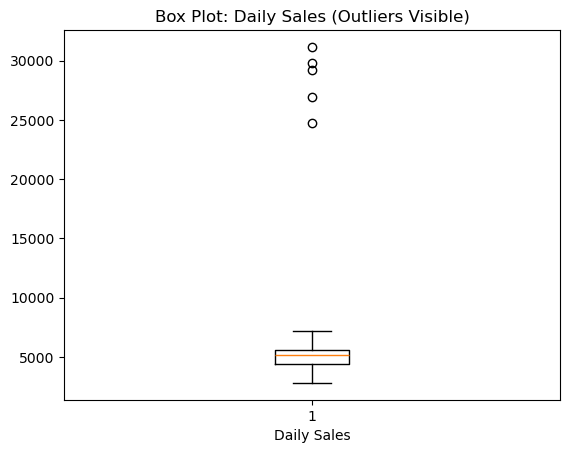

In [91]:
# --------------------------------------------------
# STEP 2: BOX PLOT (Outlier Detection)
# --------------------------------------------------
# Box plot clearly shows:
# - Median
# - Quartiles
# - Points outside whiskers = OUTLIERS
# --------------------------------------------------

plt.figure()
plt.boxplot(df["daily_sales"])
plt.title("Box Plot: Daily Sales (Outliers Visible)")
plt.xlabel("Daily Sales")
plt.show()

In [92]:
# --------------------------------------------------
# STEP 3: VIOLIN PLOT (Distribution + Outliers)
# --------------------------------------------------
# Violin plot shows:
# - Data distribution shape
# - Density
# - Extreme values stretching the distribution
# --------------------------------------------------

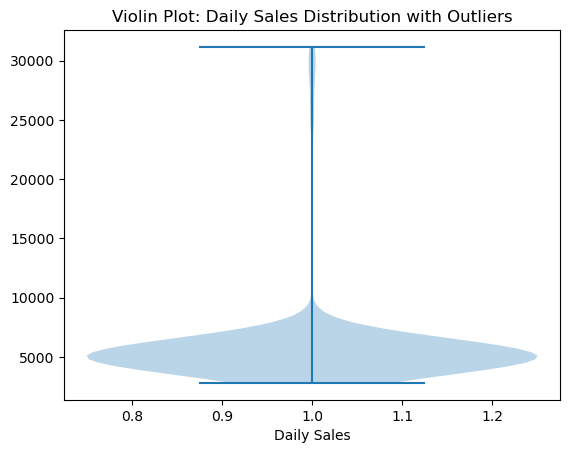

In [93]:
plt.figure()
plt.violinplot(df["daily_sales"])
plt.title("Violin Plot: Daily Sales Distribution with Outliers")
plt.xlabel("Daily Sales")
plt.show()

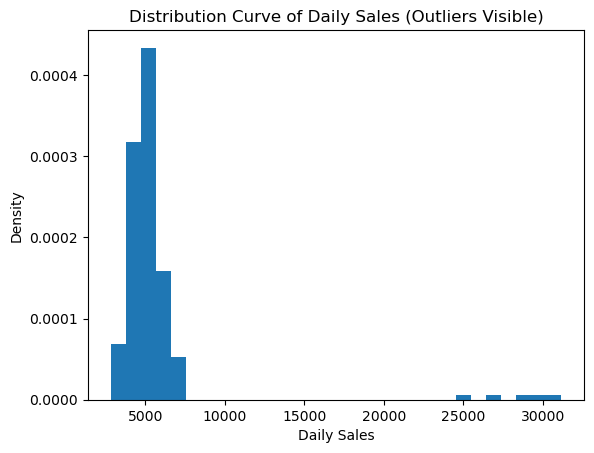

In [94]:
# Plot Distribution Curve
# --------------------------------------------
# Histogram with density=True approximates distribution curve
# Outliers will appear as a long tail on the right side
# --------------------------------------------

plt.figure()
plt.hist(df["daily_sales"], bins=30, density=True)
plt.title("Distribution Curve of Daily Sales (Outliers Visible)")
plt.xlabel("Daily Sales")
plt.ylabel("Density")
plt.show()

In [95]:
print("Key Statistics (Before Outlier Handling):\n")
print(df.describe())

Key Statistics (Before Outlier Handling):

        daily_sales
count    200.000000
mean    5630.032572
std     3763.720491
min     2810.404323
25%     4404.112237
50%     5148.650552
75%     5585.438651
max    31167.252546
